# Modelo con K Means

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm
import plotly.express as px
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

import seaborn as sns

import pandas as pd

In [2]:
df_dqi =pd.read_csv('./Data/Processed/df_dqi_final.csv', sep=';')
df_clustering_pca = pd.read_csv('./Data/Processed/df_clustering_pca.csv', sep=';')
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,False,True,False,False,False,False,False,True,False,False
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False
4,2022_01001081_02,0,0,0,0,0,0,0,3,3,...,False,True,False,False,False,False,False,True,False,False


## Entrenamiento del modelo

Se crean funciones para el entrenamiento y la evaluación del modelo.

In [3]:


def kmeans(X, clusters, sample_weight=None):
    silhouette_scores = []

    # Create a grid of subplots with 3 columns
    num_plots = len(clusters)
    rows = (num_plots + 2) // 3  # Calculate required rows
    fig, axes = plt.subplots(rows, 3, figsize=(20, rows * 5))
    axes = axes.flatten()  # Flatten in case of more than one row

    for idx, cluster in enumerate(clusters):
        kmeans = KMeans(n_clusters=cluster, random_state=42)
        labels = kmeans.fit_predict(X, sample_weight=sample_weight)  # Fit and predict clusters
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        plot_silhouette(X, labels, cluster, axes[idx])

    # Turn off any empty subplots
    for i in range(len(clusters), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
    return silhouette_scores

def plot_silhouette(X, labels, cluster, ax):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    ax.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    ax.set_title(f'Grafica de silueta para el cluster {cluster}')
    ax.set_xlabel('Coeficiente de la silueta')
    ax.set_ylabel('Cluster')

def plot_silhouette_vs_cluster(clusters, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(clusters, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Coeficiente de la silueta por clusters')
    plt.xlabel('Clusters')
    plt.ylabel('Coeficiente de la silueta')
    plt.grid(True)
    plt.show()

def plot_centroid_spider_plotly(centroids, k):
    num_features = centroids.shape[1]
    feature_labels = [f'Feature {i + 1}' for i in range(num_features)]
    
    # Prepare data for each cluster
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()  # Angles for each axis
    angles += angles[:1]  # Repeat the first angle to close the plot
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot each cluster
    for i in range(k):
        values = centroids[i].tolist() + [centroids[i][0]]  # Close the circle by repeating the first value
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {i + 1}')
        ax.fill(angles, values, alpha=0.25)

    # Add feature labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels)

    # Set the title and legend
    plt.title(f'Spider Plot for {k} Clusters')
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.show()



A continuación se realizará el proceso de clustering utilizando el método de KMeans. Para ello, se utilizará la función kmeans que recibe como parámetros los datosdespués de pasar por PCA y el rango de clusters a evaluar. En este caso, se evaluarán desde 2 hasta 10 clusters.

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\

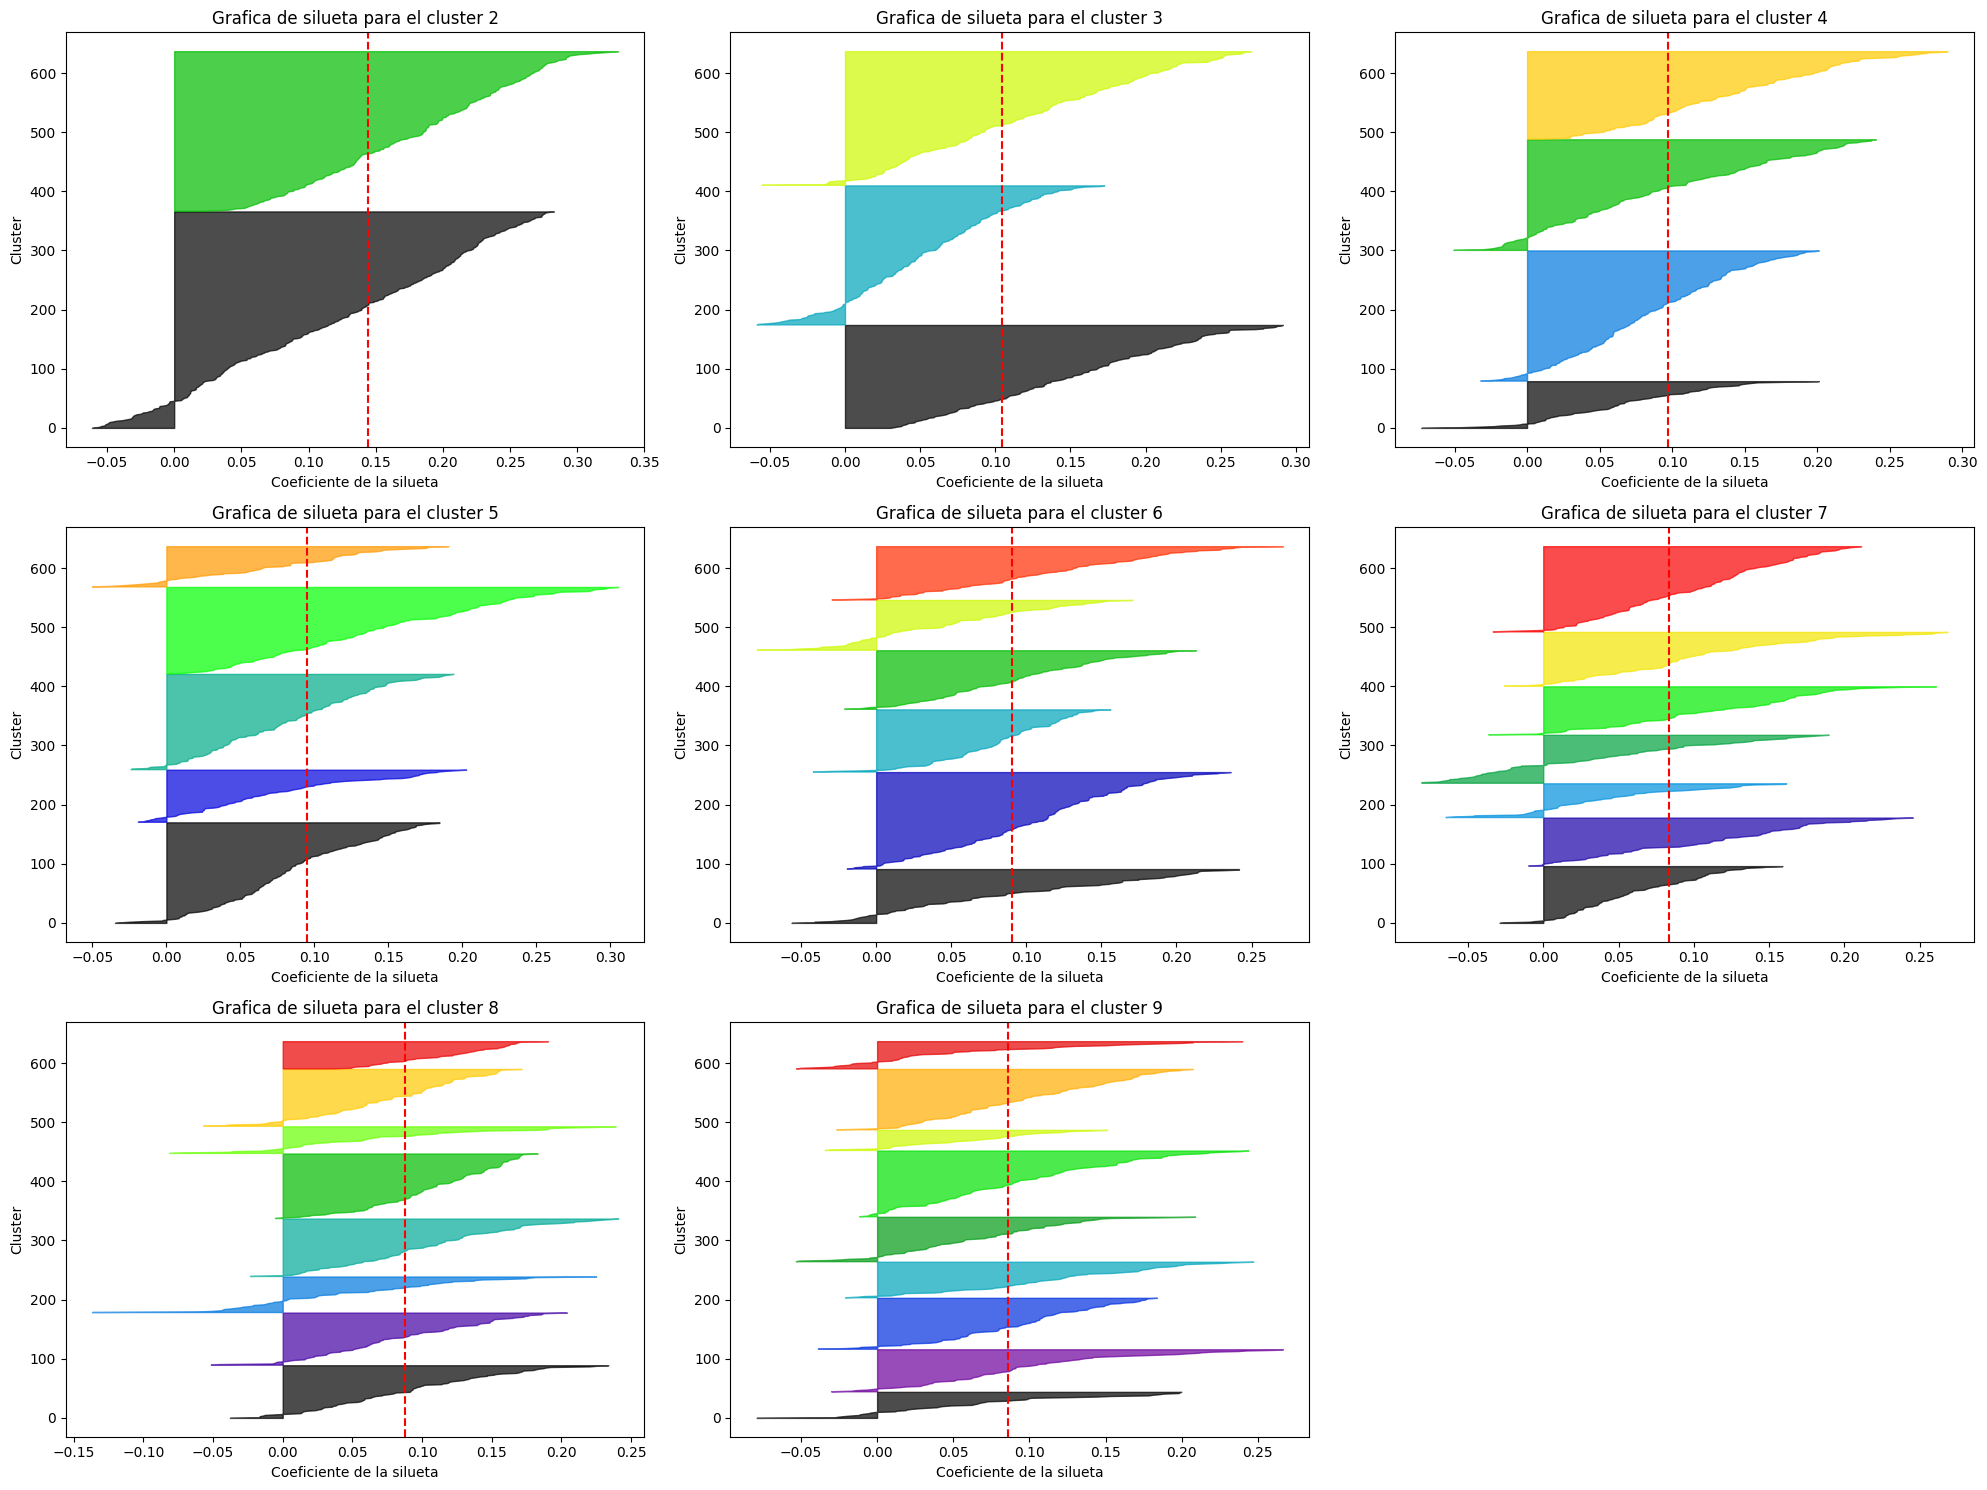

cluster = 2, Puntaje de Silueta = 0.14
cluster = 3, Puntaje de Silueta = 0.1
cluster = 4, Puntaje de Silueta = 0.1
cluster = 5, Puntaje de Silueta = 0.09
cluster = 6, Puntaje de Silueta = 0.09
cluster = 7, Puntaje de Silueta = 0.08
cluster = 8, Puntaje de Silueta = 0.09
cluster = 9, Puntaje de Silueta = 0.09


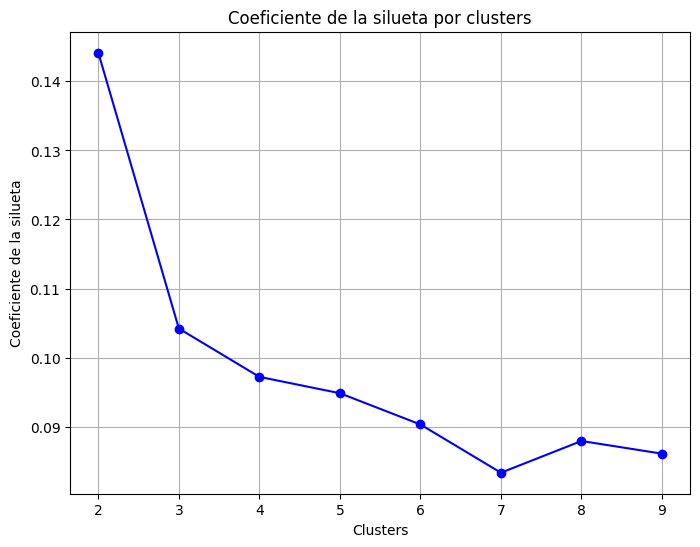

In [4]:

# Especificamos los números de clusters a evaluar
clusters = range(2, 10)  
# Ejecutamos KMeans y graficamos los resultados
silhouette_scores = kmeans(df_clustering_pca, clusters,sample_weight=df_dqi['ponderador'])
for cluster, score in zip(clusters, silhouette_scores):
    print(f'cluster = {cluster}, Puntaje de Silueta = {round(score, 2)}')
# Graficamos el coeficiente de silueta para cada número de clusters
plot_silhouette_vs_cluster(clusters, silhouette_scores)


## Interpretación del modelo

Con base en el gráfico de la silueta podemos concluir que el número de cluster óptimo para nuestro modelo de K-Means es 2, dado que con este número se obtiene el coeficiente mayor. A continuación realizaremos el análisis la segmentación realizada con este número de clusters

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


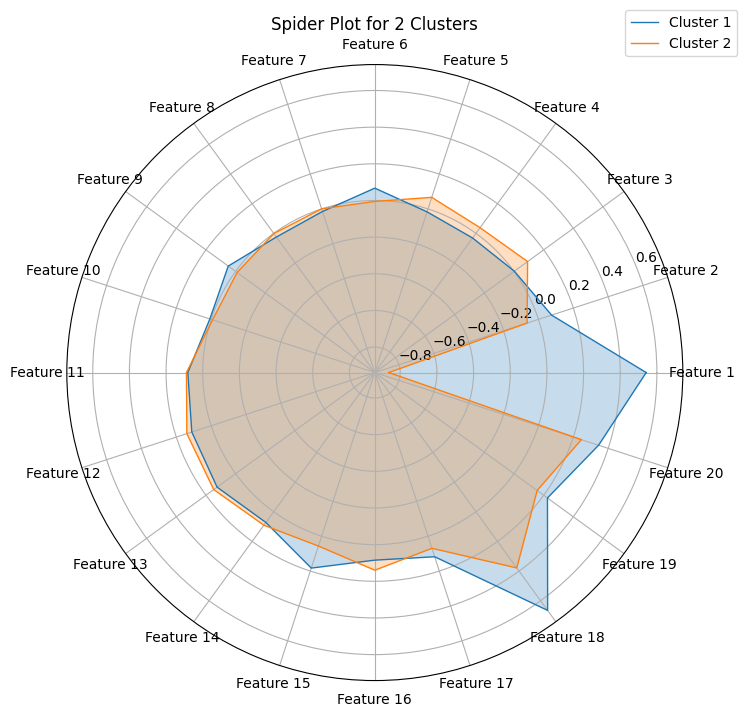

In [5]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, max_iter=10000)
labels = kmeans.fit_predict(df_clustering_pca,sample_weight=df_dqi['ponderador'])
# Obtener los centroides
centroids = kmeans.cluster_centers_

# Graficar los centroides en un gráfico radial
plot_centroid_spider_plotly(centroids, n_clusters)

Al analizar la gráfica araña podemos ver que los dos clusters tienen un comportamiento muy diferente en el primer componente principal, lo cual es bueno porque este es el componente que mayor variabilidad representa de todo el data set. A continuación realizaremos un análisis descriptivo comparando ambos clusters para identificar que representa esta diferencia.

In [6]:
df_dqi = df_dqi.assign(Cluster=labels)
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)",Cluster
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,True,False,False,False,False,False,True,False,False,1
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,True,False,False,False,False,False,True,False,False,1
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,True,False,False,False,False,False,True,False,False,1
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,True,False,False,False,False,False,True,False,False,0
4,2022_01001081_02,0,0,0,0,0,0,0,3,3,...,True,False,False,False,False,False,True,False,False,1


In [7]:
## reversar one hot encoding

df_dqi['region'] = df_dqi[['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península']].idxmax(axis=1)
df_dqi['estrato'] = df_dqi[['estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)']].idxmax(axis=1)
df_dqi.drop(columns=['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península', 'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'], inplace=True)



In [8]:
# Crear una columna sexo a partir de la columna sexo_Mujer
df_dqi['sexo'] = df_dqi['sexo_Mujer'].map({True: 'Mujer', False: 'Hombre'})
df_dqi.drop(columns=['sexo_Mujer'], inplace=True)

In [9]:
df_dqi['region'] = df_dqi['region'].apply(lambda x: x.split('_')[1])
df_dqi['estrato'] = df_dqi['estrato'].apply(lambda x: x.split('_')[1])
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,dqi_adecuacy,dqi_total,edad,ponderador,grupo,resultado_general_entrevista,Cluster,region,estrato,sexo
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,31,60,51,8717.185479,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,32,58,26,51475.173556,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,31,60,62,7032.174356,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,20,40,33,27374.852298,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
4,2022_01001081_02,0,0,0,0,0,0,0,3,3,...,37,60,60,15823.033532,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer


In [10]:
# normalizar ponderacion
df_dqi['ponderador'] = df_dqi['ponderador'].div(df_dqi['ponderador'].sum())

In [11]:
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,dqi_adecuacy,dqi_total,edad,ponderador,grupo,resultado_general_entrevista,Cluster,region,estrato,sexo
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,31,60,51,0.000122,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,32,58,26,0.000723,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,31,60,62,0.000099,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,20,40,33,0.000385,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
4,2022_01001081_02,0,0,0,0,0,0,0,3,3,...,37,60,60,0.000222,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer


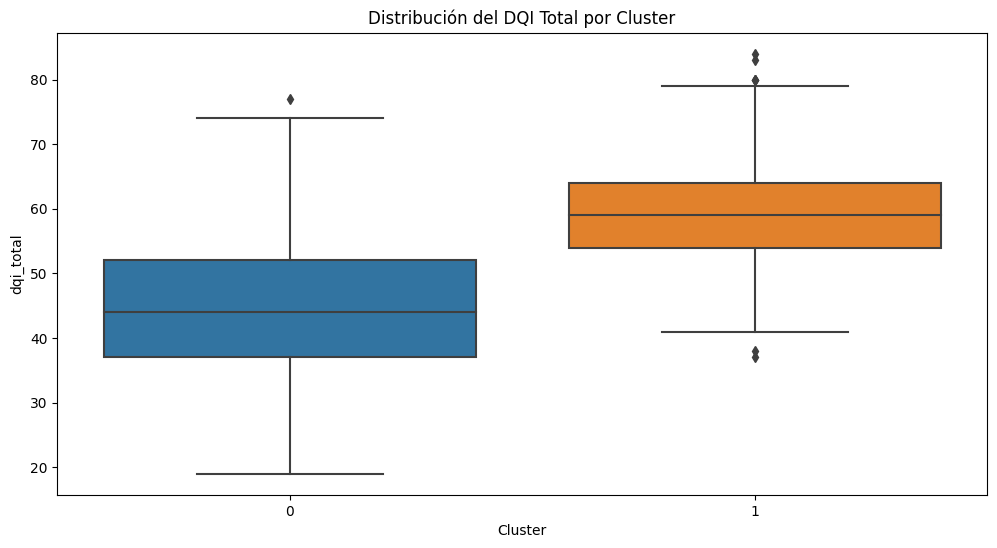

In [12]:
# generar boxplot para dos columnas
def boxplot(df, x, y, hue=None, title=None):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=x, y=y, hue=hue, data=df)
    plt.title(title)
    plt.show()

boxplot(df_dqi, 'Cluster', 'dqi_total', title='Distribución del DQI Total por Cluster')

Al analizar la gráfica anterior podemos observar que el cluster 0 tiene un valor del dqi significativamente mayor que el cluster 1, ahora analicemos si este comportamiento se presenta en todos los grupos de edad o solo a nivel general.

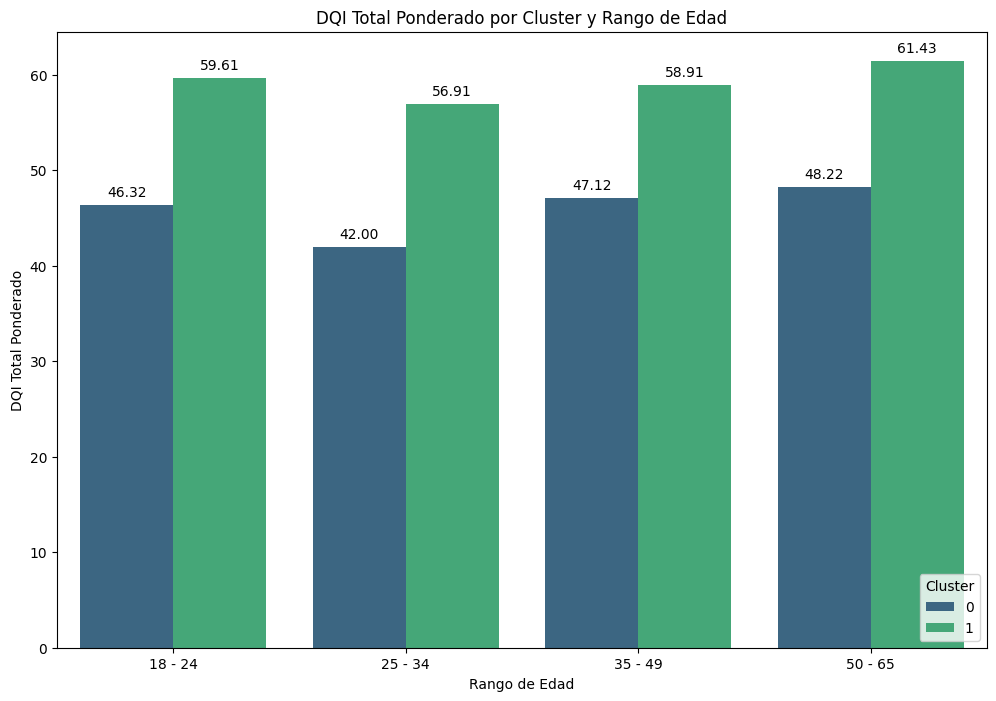

In [13]:
# Crear rangos de edad
labels = ['18 - 24', '25 - 34', '35 - 49', '50 - 65']
bins = [18, 25, 35, 50, 65]
df_dqi['edad_rango'] = pd.cut(df_dqi['edad'], bins=bins, labels=labels, right=False)

# Calcular el DQI total ponderado por género y rango de edad
weighted_dqi_by_gender_age = df_dqi.groupby(['Cluster', 'edad_rango']).apply(
    lambda x: (x['dqi_total'] * x['ponderador']).sum() / x['ponderador'].sum()
).reset_index(name='weighted_dqi_total')

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=weighted_dqi_by_gender_age, x='edad_rango', y='weighted_dqi_total', hue='Cluster', palette="viridis")
plt.title("DQI Total Ponderado por Cluster y Rango de Edad")
plt.xlabel("Rango de Edad")
plt.ylabel("DQI Total Ponderado")
plt.legend(title="Cluster", loc='lower right')

# Añadir etiquetas de datos
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

Vemos que la diferente en el valor del DQI- I total se presenta en todos los grupos edad y que esta diferencia es de entre 15 y 20 puntos.
A continuación analicemos si ambos clusters se diferencian en todos los compomentes que component el DQI-I total.

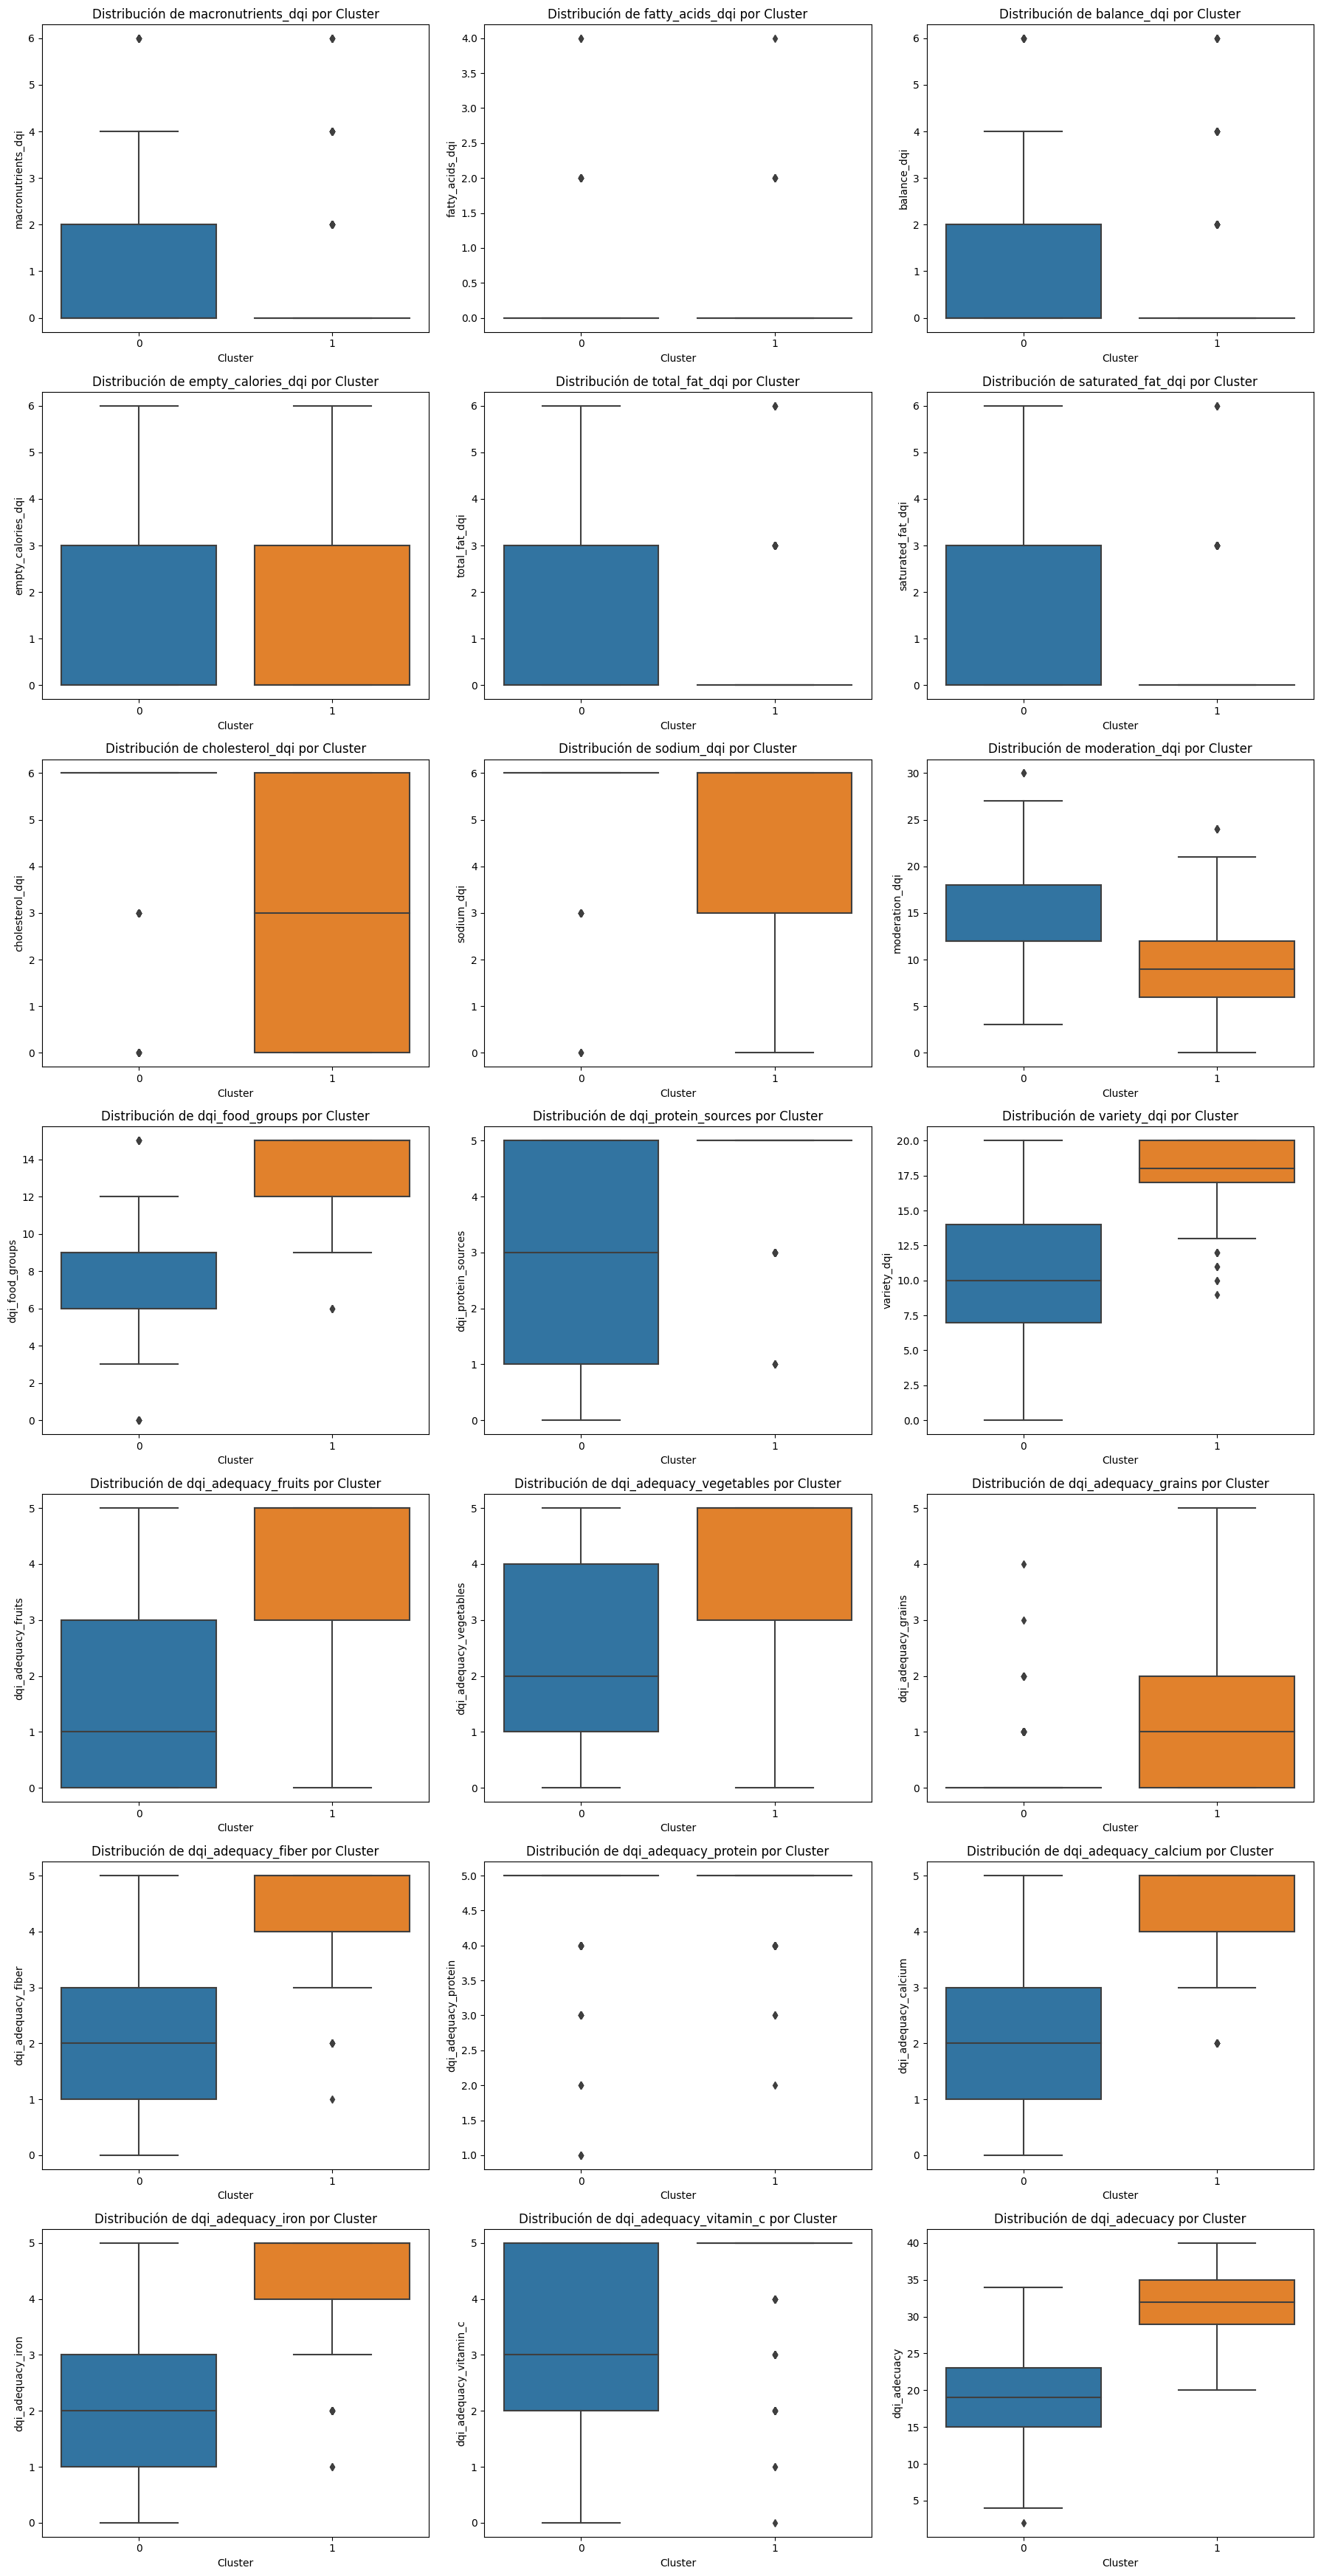

In [14]:
def boxplot_grid(df, columns, x, hue=None, n_cols=3):
    n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate the required rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = axes.flatten()  # Flatten the axis array for easy indexing

    for i, column in enumerate(columns):
        sns.boxplot(x=x, y=column, hue=hue, data=df, ax=axes[i])
        axes[i].set_title(f'Distribución de {column} por Cluster')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Select columns containing "dqi" except 'dqi_total'
dqi_columns = df_dqi.filter(like='dqi').columns
dqi_columns = dqi_columns.drop('dqi_total')

# Generate the grid of boxplots
boxplot_grid(df_dqi, dqi_columns, x='Cluster', hue=None)
    

Al anzalisar los boxplots de las variables DQI, se puede observar que el cluster 0 tiene valores más altos del DQI para casi todos los componentes del indicador. Por lo cual podemos concluir que en el cluster 0 tenemos segmentadas las personas con mejores dietas y en el cluster 1 personas con mayores brechas respecto a lo que se considera una dieta de alta calidad.